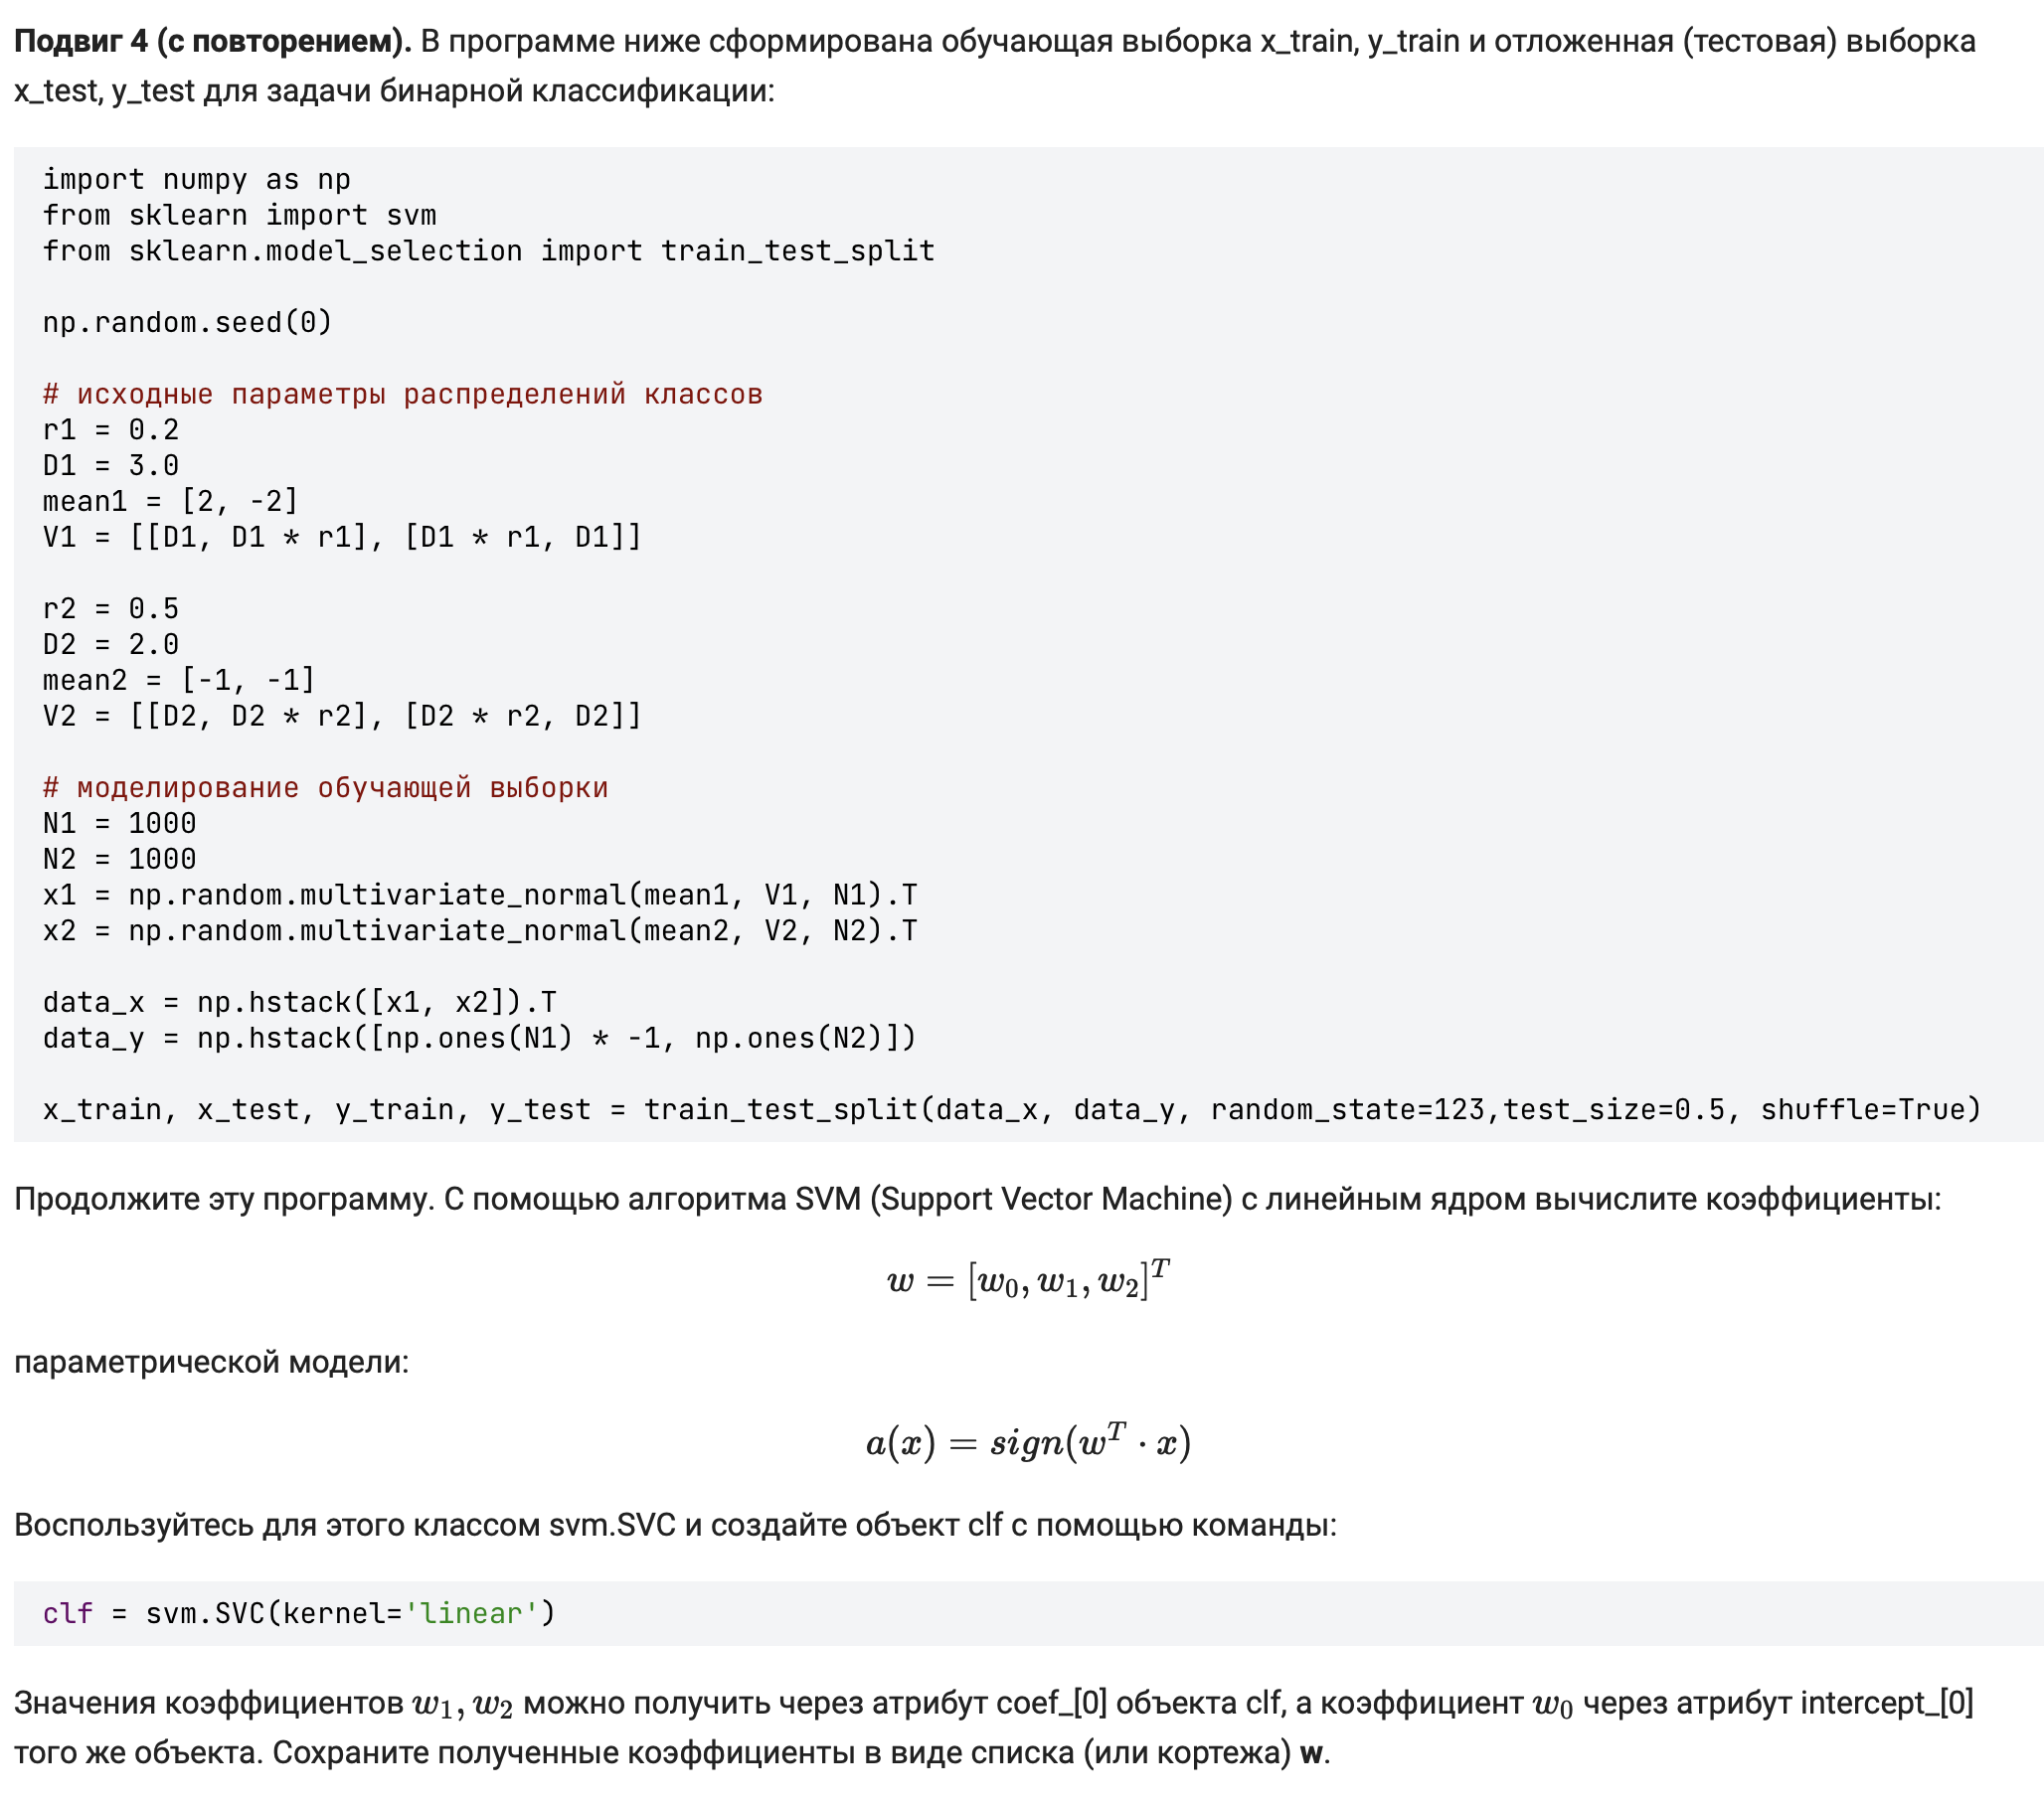
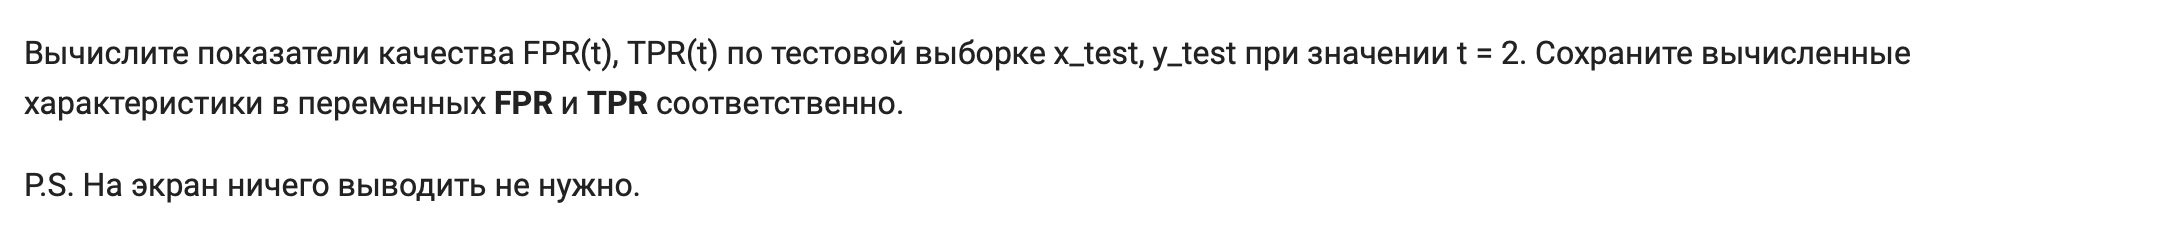

In [6]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split

np.random.seed(0)

# исходные параметры распределений классов
r1 = 0.2
D1 = 3.0
mean1 = [2, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [-1, -1]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N1 = 1000
N2 = 1000
x1 = np.random.multivariate_normal(mean1, V1, N1).T
x2 = np.random.multivariate_normal(mean2, V2, N2).T

data_x = np.hstack([x1, x2]).T
data_y = np.hstack([np.ones(N1) * -1, np.ones(N2)])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.5, shuffle=True)

x_test = np.array([[1, x[0], x[1]] for x in x_test])

# здесь продолжайте программу
model = svm.SVC(kernel='linear')
model.fit(x_train, y_train)
w12 = model.coef_[0]
w0 = model.intercept_[0]
w = np.hstack([w0, w12])

t = 2
predict = np.sign(w @ x_test.T - t)
TP = predict[(predict == 1) & (predict == y_test)].shape[0]
TN = predict[(predict == -1) & (predict == y_test)].shape[0]
FP = predict[(predict == 1) & (predict != y_test)].shape[0]
FN = predict[(predict == -1) & (predict != y_test)].shape[0]

FPR = FP / (FP + TN)
TPR = TP / (TP + FN)
FPR, TPR

(0.023715415019762844, 0.4574898785425101)

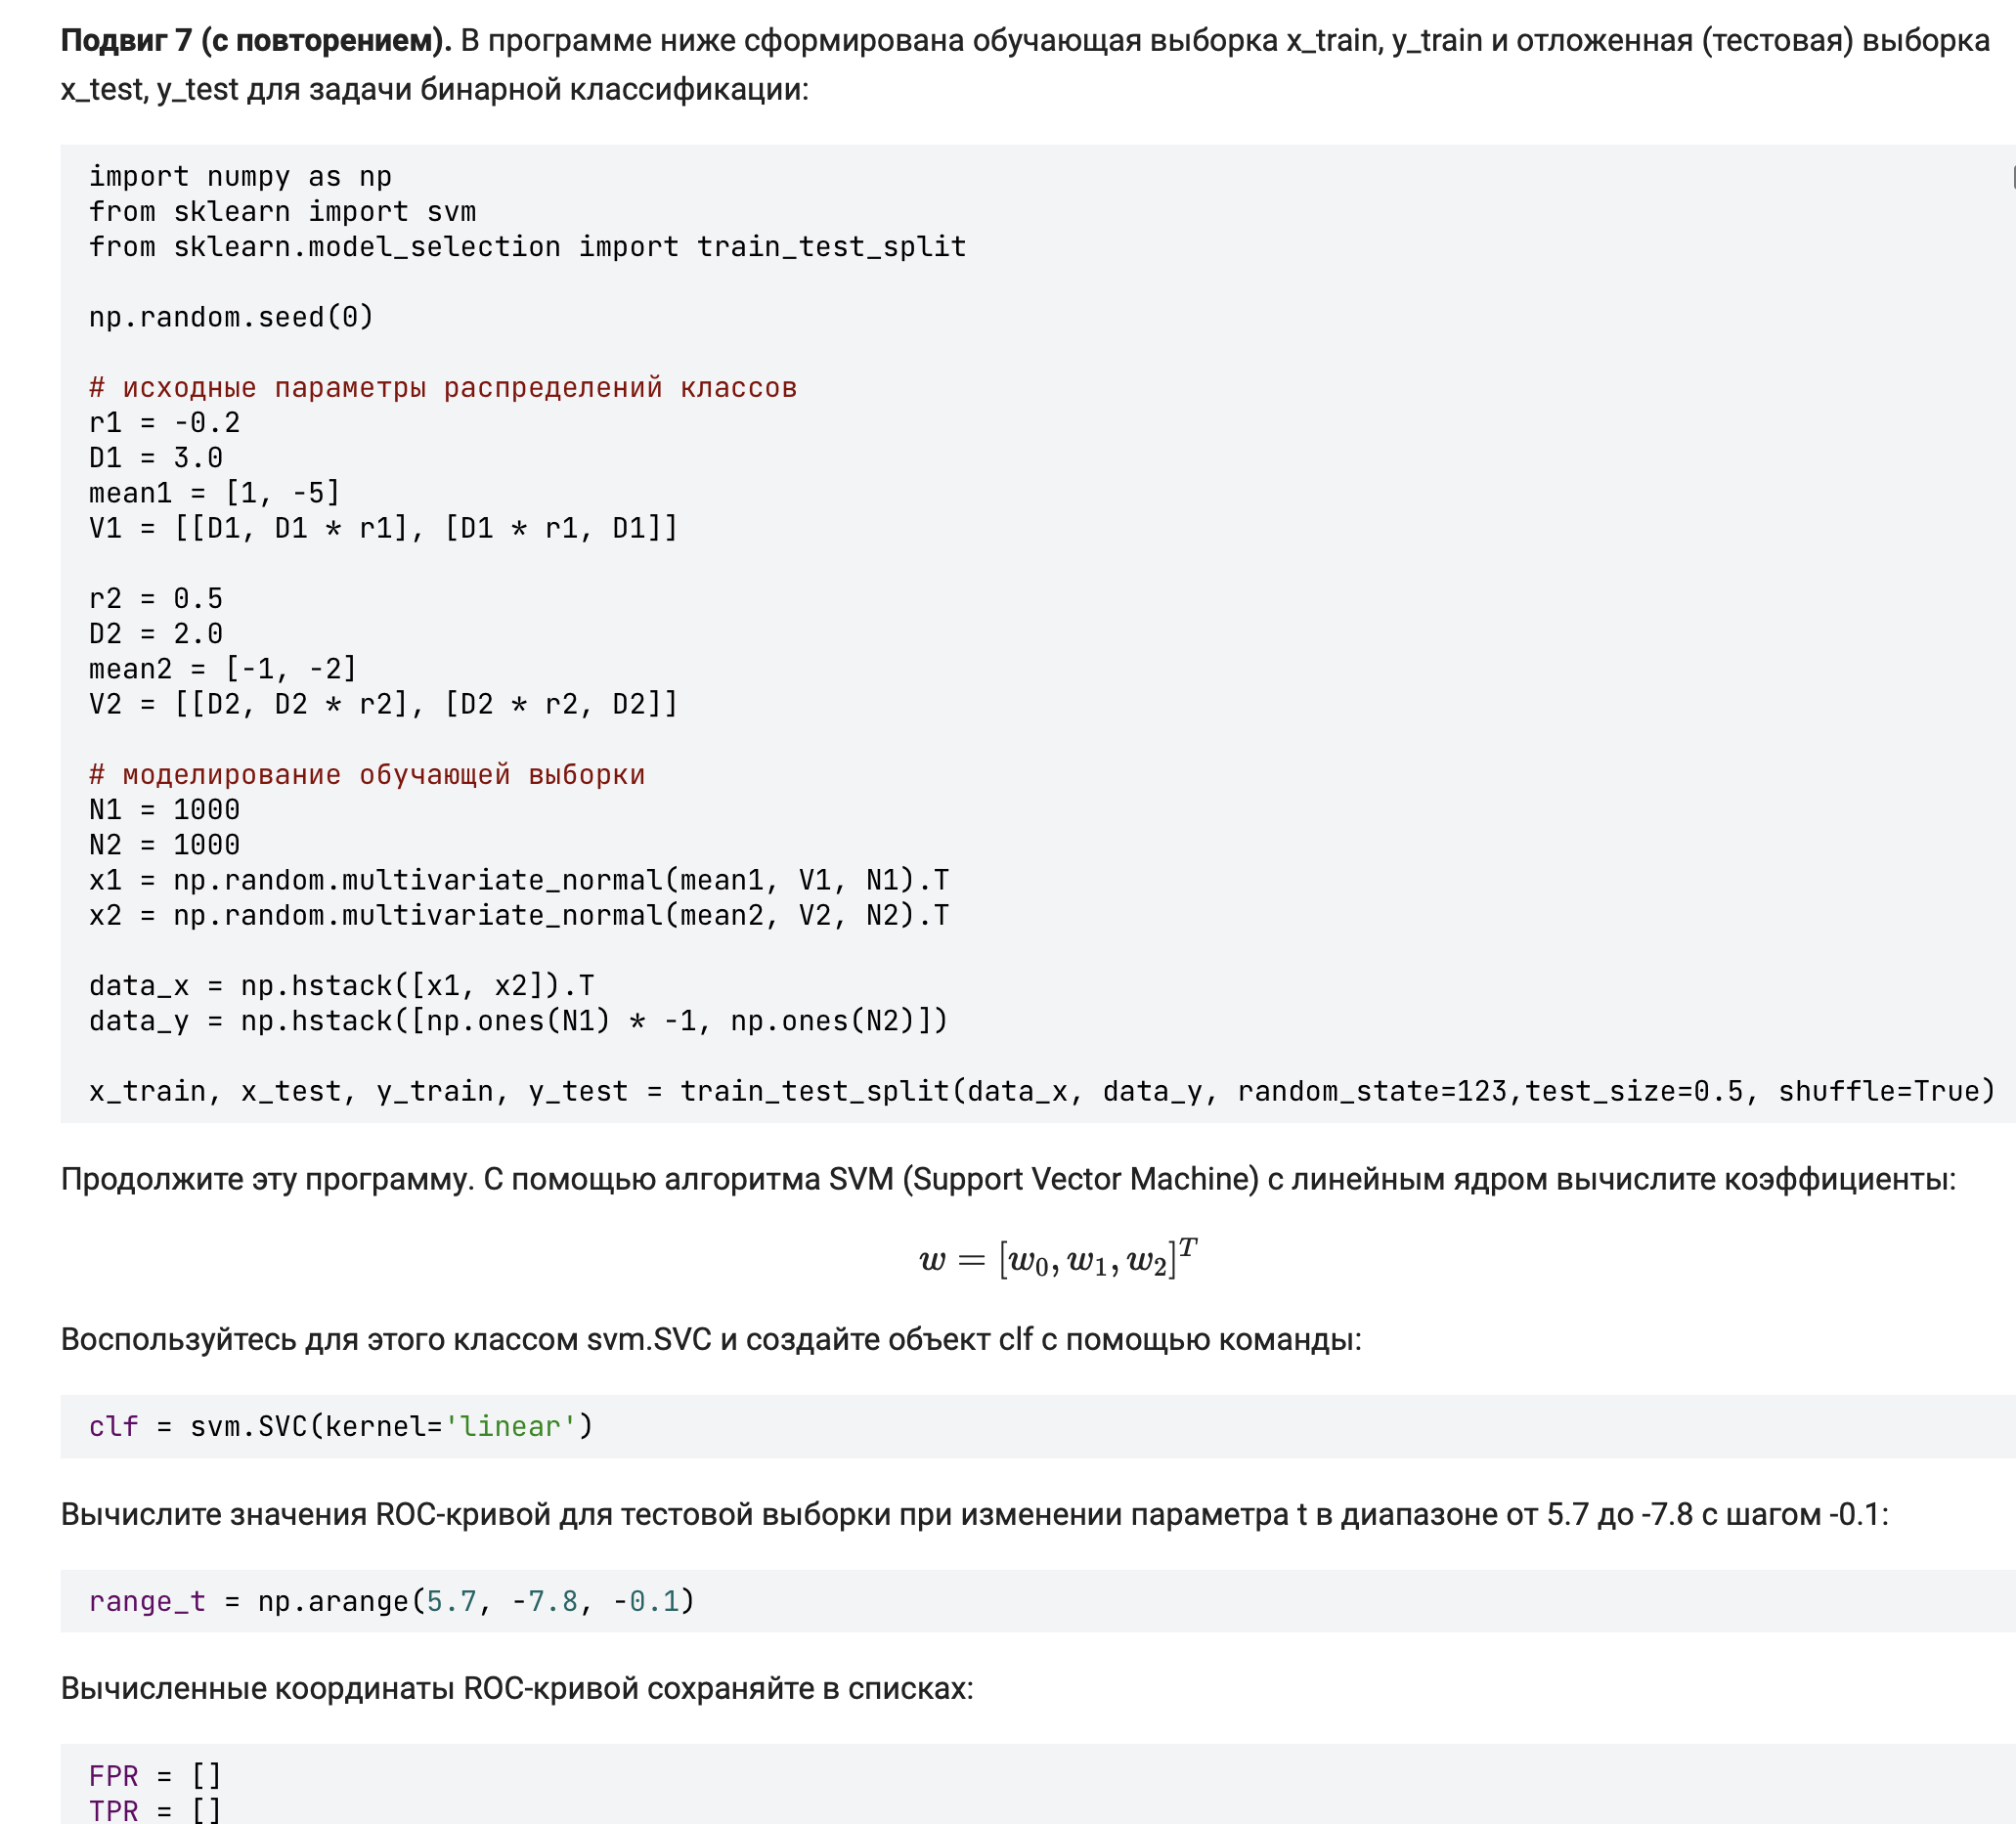

In [2]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split

np.random.seed(0)

# исходные параметры распределений классов
r1 = -0.2
D1 = 3.0
mean1 = [1, -5]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [-1, -2]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N1 = 1000
N2 = 1000
x1 = np.random.multivariate_normal(mean1, V1, N1).T
x2 = np.random.multivariate_normal(mean2, V2, N2).T

data_x = np.hstack([x1, x2]).T
data_y = np.hstack([np.ones(N1) * -1, np.ones(N2)])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.5, shuffle=True)
x_test = np.array([[1, x[0], x[1]] for x in x_test])

# здесь продолжайте программу
model = svm.SVC(kernel='linear')
model.fit(x_train, y_train)
w = np.hstack([model.intercept_[0], model.coef_[0]])

range_t = np.arange(5.7, -7.8, -0.1)
FPR = []
TPR = []
for t in range_t:
    predict = np.sign(w @ x_test.T - t)

    TP = predict[(predict == 1) & (predict == y_test)].shape[0]
    TN = predict[(predict == -1) & (predict == y_test)].shape[0]
    FP = predict[(predict == 1) & (predict != y_test)].shape[0]
    FN = predict[(predict == -1) & (predict != y_test)].shape[0]

    FPR += [FP / (FP + TN)]
    TPR += [TP / (TP + FN)]